# 03 · Regiões e municípios: onde o Pix é mais usado?

**Pergunta 4:** onde o Pix é mais usado? Quais regiões cresceram mais?

Aqui entra uma ideia central em análise de dados: **números absolutos enganam quando os grupos têm tamanhos diferentes**. São Paulo sempre vai liderar em quantidade de Pix, porque tem 46 milhões de habitantes. Para comparar de forma justa, precisamos **normalizar pela população**, ou seja, calcular o **Pix por habitante**.

**Dados:** Pix por município (Banco Central) + população estimada por município (IBGE), coletados por `src/coleta.py` e `src/coleta_ibge.py`.

In [1]:
import sys, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import LinearSegmentedColormap, Normalize

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import estilo, categorias as cat
from estilo import br

estilo.aplicar()
pd.set_option("display.float_format", lambda v: br(v, 1))

mun = pd.read_parquet(RAIZ / "data/raw/municipios.parquet")
pop = pd.read_parquet(RAIZ / "data/raw/populacao.parquet")
print(pop["fonte"].iloc[0], "·", pop["ano_populacao"].iloc[0], "·", f"{pop['populacao'].sum():,.0f} habitantes".replace(",", "."))

Estimativas de população (IBGE, API de Agregados) · 2026 · 214.211.951 habitantes


## 1. Cortando o mês incompleto

A base de municípios traz o **mês corrente pela metade**. Para não criar uma "queda" falsa no fim das séries, usamos como último mês o último **fechado** da base nacional de estatísticas.

In [2]:
ultimo = int(pd.read_parquet(RAIZ / "data/raw/estatisticas.parquet", columns=["AnoMes"])["AnoMes"].max())
print("Meses na base de municípios:", sorted(mun["AnoMes"].unique())[-3:], "→ usando até", ultimo)

mun = mun[(mun["AnoMes"] <= ultimo) & (mun["Regiao"] != "Nao informado")].copy()
mun["mes"] = cat.para_data(mun["AnoMes"])
mun["qtd_total"] = mun["QT_PagadorPF"] + mun["QT_PagadorPJ"]

Meses na base de municípios: [np.int64(202607), np.int64(202608), np.int64(202609)] → usando até 202608


## 2. A participação de cada região mudou?

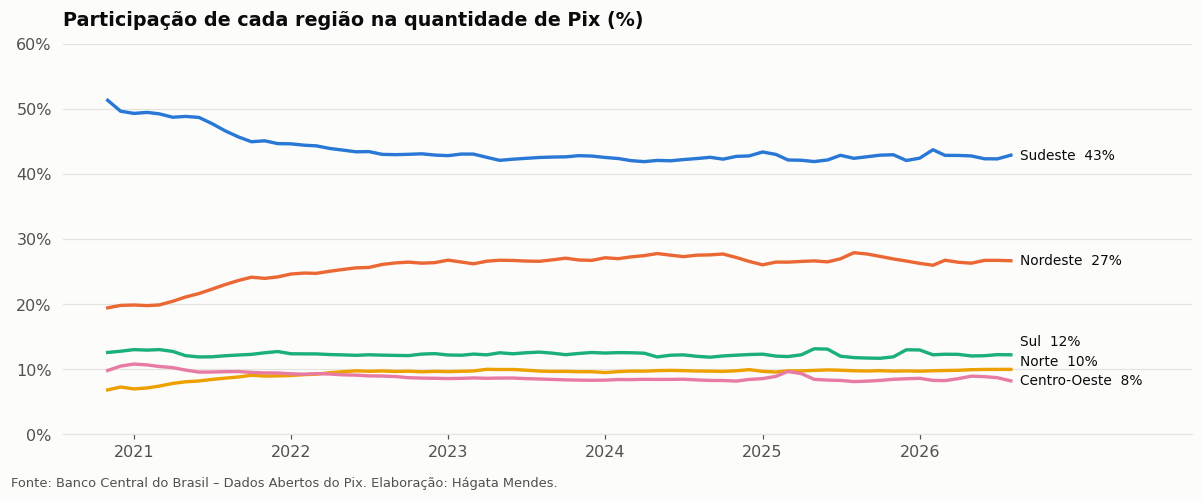

mes,nov/2020,ago/2026
Regiao,,
SUDESTE,"51,3","42,9"
NORDESTE,"19,4","26,7"
SUL,"12,6","12,2"
NORTE,"6,8","10,0"
CENTRO-OESTE,"9,8","8,2"


In [3]:
REGIOES = ["SUDESTE", "NORDESTE", "SUL", "NORTE", "CENTRO-OESTE"]
cores_r = dict(zip(REGIOES, estilo.CATEGORICAS))

reg = mun.pivot_table(index="mes", columns="Regiao", values="qtd_total", aggfunc="sum")[REGIOES]
part_reg = reg.div(reg.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4.4))
for r in REGIOES:
    ax.plot(part_reg.index, part_reg[r], color=cores_r[r])
ax.set_ylim(0, 60)
estilo.rotulos_finais(ax, {f"{r.title()}  {br(part_reg[r].iloc[-1], 0)}%": part_reg[r] for r in REGIOES})
anos = range(part_reg.index[0].year + 1, part_reg.index[-1].year + 1)
ax.set_xticks([pd.Timestamp(a, 1, 1) for a in anos], [str(a) for a in anos])
ax.set_xlim(right=part_reg.index[-1] + pd.Timedelta(days=420))
ax.set_title("Participação de cada região na quantidade de Pix (%)")
estilo.eixo_br(ax, 0, "%")
estilo.fonte(fig)
plt.tight_layout(); plt.show()

part_reg.iloc[[0, -1]].T.rename(columns=lambda d: f"{estilo.mes_abrev(d)}/{d.year}")

**Leitura:**
- No lançamento, o **Sudeste** concentrava **51%** dos Pix. Hoje concentra **43%**. O **Nordeste** subiu de **19%** para **27%**, e o **Norte** de **7%** para **10%**.
- Essa mudança aconteceu quase toda nos **dois primeiros anos**. Desde 2023 as linhas estão praticamente paralelas, ou seja, todas as regiões crescem no mesmo ritmo.
- Hoje a participação de cada região é **muito parecida com o peso da sua população**. O Nordeste tem 26,8% dos habitantes e 27% dos Pix. As exceções são o **Norte**, que usa acima do seu peso (8,8% da população), e o **Sul**, que usa abaixo (14,7% da população e 12% dos Pix).

👉 O Pix começou pelo Sudeste, mas **em cerca de dois anos o resto do país alcançou**. O próximo passo é olhar o uso **por habitante**, que confirma essa leitura.

## 3. Pix por habitante

### 3.1 Uma armadilha: onde a empresa está registrada

Se dividirmos **todos** os Pix pela população, aparecem distorções. Veja Barueri (SP), sede de muitas empresas em Alphaville:

In [4]:
ult12 = mun[mun["AnoMes"] > ultimo - 100]          # últimos 12 meses
por_mun = (ult12.groupby("Municipio_Ibge")
           .agg(municipio=("Municipio", "first"), estado=("Estado", "first"), regiao=("Regiao", "first"),
                pix_total=("qtd_total", "sum"), pix_pf=("QT_PagadorPF", "sum"))
           .join(pop.set_index("Municipio_Ibge")["populacao"]))
por_mun["total_por_hab_mes"] = por_mun["pix_total"] / por_mun["populacao"] / 12
por_mun["pf_por_hab_mes"] = por_mun["pix_pf"] / por_mun["populacao"] / 12

por_mun.loc[por_mun["municipio"].isin(["BARUERI", "SÃO PAULO"]),
            ["municipio", "populacao", "total_por_hab_mes", "pf_por_hab_mes"]].set_index("municipio")

,populacao,total_por_hab_mes,pf_por_hab_mes
municipio,,,
BARUERI,336015,"119,4","30,8"
SÃO PAULO,11911337,"47,0","28,5"


Barueri teria **mais que o dobro** de Pix por habitante da capital paulista. O motivo é que os Pix feitos **por empresas** são contados no município onde a empresa está registrada, e não onde as pessoas moram.

**Solução:** como "por habitante" é sobre **pessoas**, usamos só os Pix feitos por **pessoas físicas** (`QT_PagadorPF`). Assim a métrica mede o hábito da população, e não onde ficam as sedes das empresas. Esse tipo de decisão metodológica, explicada, é o que diferencia uma análise cuidadosa de uma apressada.

### 3.2 Por estado, no mapa

Métrica: **quantos Pix cada habitante faz por mês** (média dos últimos 12 meses, só pessoas físicas).

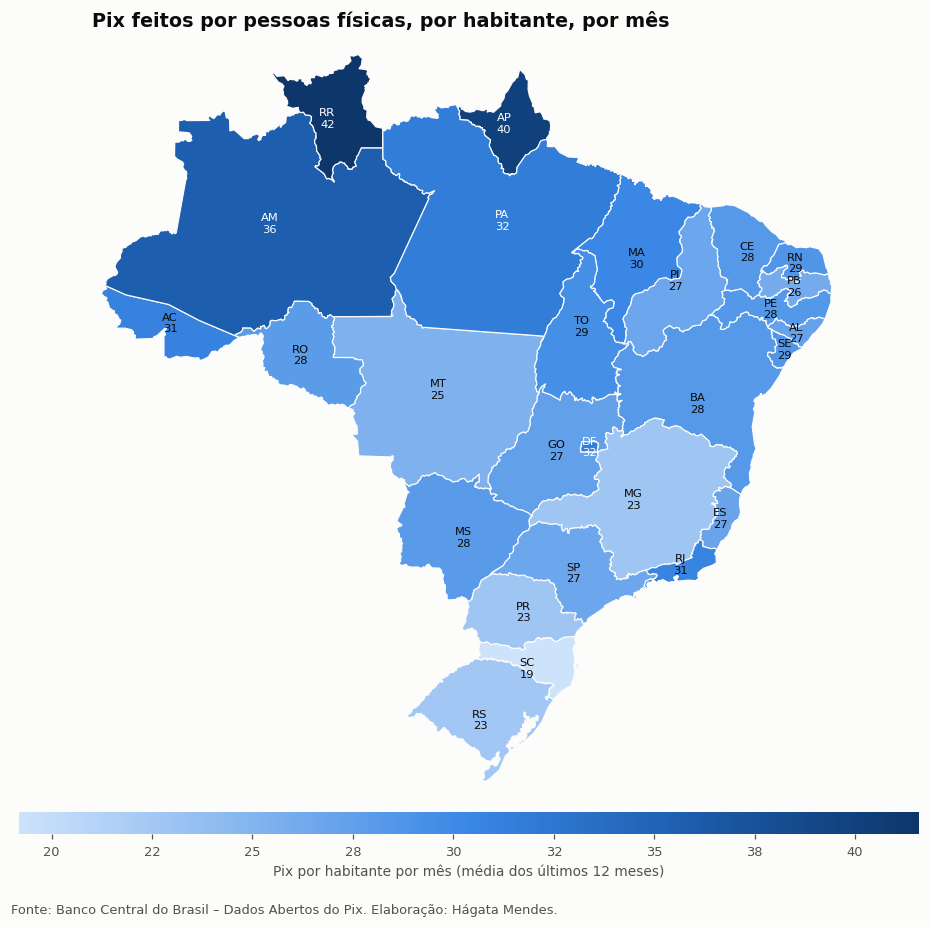

In [5]:
por_uf = por_mun.groupby("estado")[["pix_pf", "populacao"]].sum()
por_uf["pix_por_hab_mes"] = por_uf["pix_pf"] / por_uf["populacao"] / 12

geo = json.loads((RAIZ / "data/geo/estados.geojson").read_text())
nome_para_sigla = {f["properties"]["nome"].upper(): f["properties"]["sigla"] for f in geo["features"]}
por_uf["sigla"] = por_uf.index.map(nome_para_sigla)
assert por_uf["sigla"].notna().all(), "algum estado não casou com o mapa"
valores = por_uf.set_index("sigla")["pix_por_hab_mes"]

azuis = LinearSegmentedColormap.from_list("azuis", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
norm = Normalize(valores.min(), valores.max())

fig, ax = plt.subplots(figsize=(8.5, 8.2))
for f in geo["features"]:
    sigla, g = f["id"], f["geometry"]
    poligonos = g["coordinates"] if g["type"] == "MultiPolygon" else [g["coordinates"]]
    for poli in poligonos:
        ax.add_patch(Polygon(poli[0], closed=True, facecolor=azuis(norm(valores[sigla])),
                             edgecolor=estilo.FUNDO, linewidth=0.8))
    xs = [p[0] for p in poligonos[0][0]]; ys = [p[1] for p in poligonos[0][0]]
    cx, cy = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
    escuro = norm(valores[sigla]) > 0.55
    ax.text(cx, cy, f"{sigla}\n{br(valores[sigla], 0)}", ha="center", va="center", fontsize=7.5,
            color="white" if escuro else estilo.TEXTO)
ax.set_xlim(-74.5, -34); ax.set_ylim(-34.5, 5.8); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Pix feitos por pessoas físicas, por habitante, por mês")
barra = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=azuis), ax=ax, orientation="horizontal",
                     fraction=0.035, pad=0.02, aspect=40)
barra.outline.set_visible(False); barra.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: br(v, 0))); barra.ax.tick_params(colors=estilo.TEXTO_2, labelsize=8.5)
barra.set_label("Pix por habitante por mês (média dos últimos 12 meses)", color=estilo.TEXTO_2, fontsize=9)
estilo.fonte(fig)
plt.tight_layout(); plt.show()

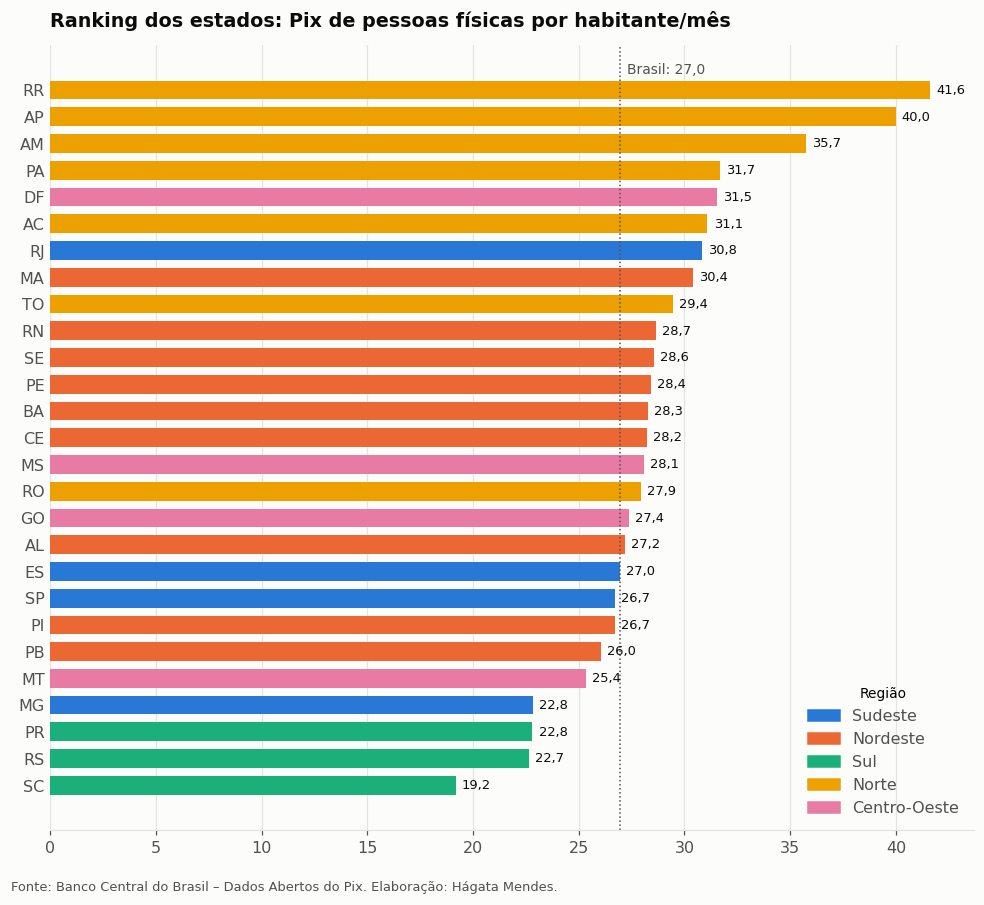

In [6]:
rank = por_uf.sort_values("pix_por_hab_mes")
regiao_uf = por_mun.groupby("estado")["regiao"].first()
brasil = por_uf["pix_pf"].sum() / por_uf["populacao"].sum() / 12

fig, ax = plt.subplots(figsize=(9, 8))
barras = ax.barh(rank["sigla"], rank["pix_por_hab_mes"], color=[cores_r[regiao_uf[e]] for e in rank.index], height=0.7)
for b in barras:
    ax.annotate(br(b.get_width(), 1), (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8.5, color=estilo.TEXTO)
ax.axvline(brasil, color=estilo.TEXTO_2, lw=1, ls=":")
ax.annotate(f"Brasil: {br(brasil, 1)}", (brasil, len(rank) - 0.4), xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=estilo.TEXTO_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.tick_params(axis="y", length=0)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=cores_r[r]) for r in REGIOES],
          labels=[r.title() for r in REGIOES], loc="lower right", title="Região", title_fontsize=9)
ax.set_title("Ranking dos estados: Pix de pessoas físicas por habitante/mês")
estilo.fonte(fig)
plt.tight_layout(); plt.show()

**Leitura: o mapa inverte a intuição.**
- Quem mais usa o Pix, por habitante, é o **Norte**: **Roraima (41,6)**, **Amapá (40,0)** e **Amazonas (35,7)** Pix por pessoa por mês.
- Quem menos usa é o **Sul**: **Santa Catarina (19,2)**, Rio Grande do Sul (22,7) e Paraná (22,8), junto com Minas Gerais (22,8).
- **São Paulo**, que lidera em números absolutos, fica **abaixo da média nacional** (26,7 contra 27,0).

**Hipóteses para investigar** (os dados não provam o porquê):
- No Norte, onde há menos agências bancárias e menos uso de cartão, o Pix pode ter virado o **principal meio de pagamento**, e não só mais uma opção.
- No Sul, o cartão e as **cooperativas de crédito** tradicionalmente têm mais força, e o Pix concorre com hábitos já estabelecidos.

### 3.3 Cidades grandes: quem mais e quem menos usa

Para evitar distorções de cidades muito pequenas (onde poucos casos mudam muito a média), filtramos municípios com **100 mil habitantes ou mais**.

In [7]:
grandes = por_mun[por_mun["populacao"] >= 100_000]
colunas = {"municipio": "Município", "estado": "Estado", "populacao": "População", "pf_por_hab_mes": "Pix/hab/mês"}
top = grandes.nlargest(10, "pf_por_hab_mes")[list(colunas)].rename(columns=colunas)
base = grandes.nsmallest(10, "pf_por_hab_mes")[list(colunas)].rename(columns=colunas)
print(f"{len(grandes)} municípios com 100 mil+ habitantes")
display(top.style.format({"População": lambda v: br(v, 0), "Pix/hab/mês": lambda v: br(v, 1)}).hide(axis="index").set_caption("🔝 Os 10 que mais usam"))
display(base.style.format({"População": lambda v: br(v, 0), "Pix/hab/mês": lambda v: br(v, 1)}).hide(axis="index").set_caption("🔻 Os 10 que menos usam"))

338 municípios com 100 mil+ habitantes


Município,Estado,População,Pix/hab/mês
MANAUS,AMAZONAS,2.327.101,"47,2"
BELÉM,PARÁ,1.396.157,"44,9"
QUEIMADOS,RIO DE JANEIRO,149.155,"44,7"
SANTARÉM,PARÁ,364.298,"43,6"
SÃO LUÍS,MARANHÃO,1.090.229,"43,3"
SIMÕES FILHO,BAHIA,120.429,"43,2"
SANTANA,AMAPÁ,119.224,"43,0"
ANANINDEUA,PARÁ,510.563,"43,0"
SALVADOR,BAHIA,2.559.945,"42,3"
MACAPÁ,AMAPÁ,491.987,"42,2"


Município,Estado,População,Pix/hab/mês
CHAPECÓ,SANTA CATARINA,289.170,"17,3"
ERECHIM,RIO GRANDE DO SUL,109.610,"17,7"
FRANCISCO BELTRÃO,PARANÁ,103.424,"17,7"
BENTO GONÇALVES,RIO GRANDE DO SUL,127.980,"18,1"
BRUSQUE,SANTA CATARINA,158.593,"18,4"
JARAGUÁ DO SUL,SANTA CATARINA,203.204,"18,6"
ITAÚNA,MINAS GERAIS,104.002,"18,6"
UMUARAMA,PARANÁ,124.077,"18,7"
TUBARÃO,SANTA CATARINA,117.924,"18,7"
BARBACENA,MINAS GERAIS,129.757,"19,4"


**Leitura:** entre as 338 cidades com mais de 100 mil habitantes, **todas as 10 que mais usam** o Pix por habitante ficam no **Norte e no Nordeste**, ou na Baixada Fluminense, com capitais como **Manaus (47,2)**, **Belém (44,9)**, **São Luís (43,3)** e **Salvador (42,3)**. As que menos usam se concentram no **interior do Sul**, como Chapecó, Erechim e Francisco Beltrão, com cerca de 17 a 18 Pix por habitante por mês, menos da metade de Manaus.

## 4. Conclusões

| Pergunta | Resposta |
|---|---|
| **Onde se faz mais Pix (volume)?** | No **Sudeste** (43%), mas isso reflete o tamanho da população |
| **Quem cresceu mais?** | **Nordeste** (19% → 27%) e **Norte** (7% → 10%), quase tudo até 2022. Hoje a divisão acompanha a população |
| **Onde se usa mais, por habitante?** | No **Norte**: Roraima, Amapá e Amazonas lideram com 36 a 42 Pix por pessoa por mês |
| **Onde se usa menos?** | No **Sul** e em Minas Gerais: Santa Catarina tem 19 Pix por pessoa por mês |
| **Média do Brasil** | **27 Pix por habitante por mês**, quase **um por dia** para cada brasileiro |

**Lições de análise deste notebook:** (1) **normalize** antes de comparar grupos de tamanhos diferentes; (2) escolha o numerador certo (só pessoas físicas) para a métrica medir o que você quer; (3) filtre casos pequenos, como municípios com menos de 100 mil habitantes, antes de fazer rankings; (4) separe o que os dados **mostram** das **hipóteses** sobre o porquê.

> ⚠️ **Limites da análise:** (1) usamos a população estimada do IBGE, e estados com muitos migrantes não recenseados, como Roraima, podem ter o uso por habitante superestimado; (2) os dados mostram **onde** o Pix acontece, não **por quê**, e as explicações acima são **hipóteses** que precisariam de outros dados (uso de cartão, crédito, bancarização) para serem confirmadas.